# Holotomography 3D — Synthetic Self-Test

End-to-end verification of the `Rec` reconstruction class on fully synthetic data:
1. Build a phantom object and a realistic probe.
2. Forward-simulate diffraction patterns and a flat-field reference.
3. Run the iterative reconstruction and check convergence.

In [1]:
import numpy as np
import cupy as cp
import h5py
from scipy.fft import fftn, ifftn, fftshift, fft2, ifft2
import scipy.ndimage as ndimage
from mpi4py import MPI

from holotomocupy.rec_mpi import Rec
from holotomocupy.utils import *   # mshow, mshow_complex, mshow_polar, mshow_pos, read_tiff

## Acquisition Parameters

In [2]:
n      = 256                                          # detector size (pixels)
ntheta = 360                                          # number of projection angles
ndist  = 4                                            # number of propagation distances

energy                  = 17.1                        # X-ray energy (keV)
detector_pixelsize      = 1.4760147601476e-6 * 2 * 8 # effective pixel size (m), binned
focustodetectordistance = 1.217                       # focus-to-detector distance (m)
z1 = np.array([5.110, 5.464, 6.879, 9.817]) * 1e-3  # sample-to-focus distances (m)

nobj = 3 * n // 2  # object volume side length (pixels)

## Synthetic Phantom Object

Build a complex-valued 3-D phantom: several nested wire-frame cubes convolved with spheres of varying radii, rotated and smoothed.
The real part encodes the refractive index decrement δ, the imaginary part encodes the absorption β.

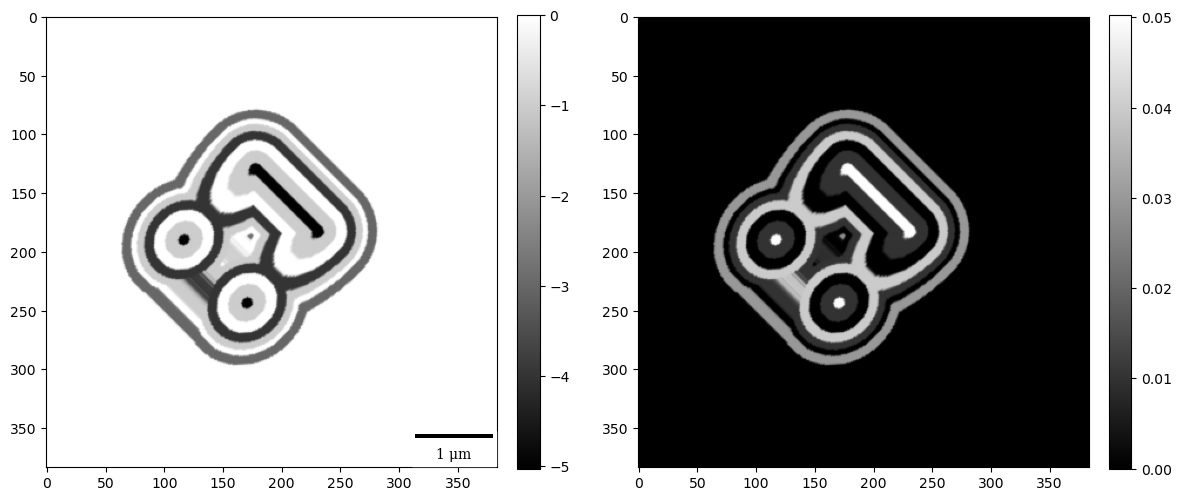

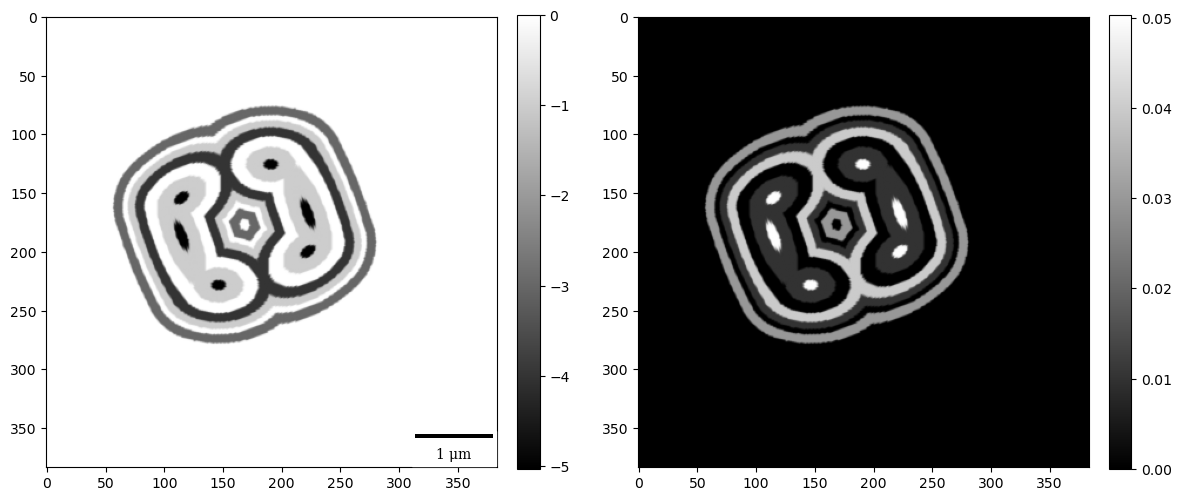

In [3]:
def _draw_frame_edges_inplace(cube, p1, p2):
    """Draw edges into cube (assumes cube already zero)."""
    # Edges parallel to x
    cube[p1:p2, p1, p1] = 1; cube[p1:p2, p1, p2] = 1
    cube[p1:p2, p2, p1] = 1; cube[p1:p2, p2, p2] = 1
    # Edges parallel to y
    cube[p1, p1:p2, p1] = 1; cube[p1, p1:p2, p2] = 1
    cube[p2, p1:p2, p1] = 1; cube[p2, p1:p2, p2] = 1
    # Edges parallel to z
    cube[p1, p1, p1:p2] = 1; cube[p1, p2, p1:p2] = 1
    cube[p2, p1, p1:p2] = 1; cube[p2, p2, p1:p2] = 1

def rotate3d_once(vol, ang_xy_deg=28, ang_xz_deg=45, order=1):
    # angles in radians
    a = np.deg2rad(ang_xy_deg)  # rotation in (0,1) plane = about z-axis
    b = np.deg2rad(ang_xz_deg)  # rotation in (0,2) plane = about y-axis

    Rz = np.array([[ np.cos(a), -np.sin(a), 0],
                   [ np.sin(a),  np.cos(a), 0],
                   [ 0,          0,         1]], dtype=np.float64)

    Ry = np.array([[ np.cos(b), 0, np.sin(b)],
                   [ 0,         1, 0        ],
                   [-np.sin(b), 0, np.cos(b)]], dtype=np.float64)

    R = Ry @ Rz  # apply z-rot then y-rot (matches sequential calls order)

    # affine_transform uses inverse mapping:
    A = np.linalg.inv(R)

    center = (np.array(vol.shape) - 1) / 2.0
    offset = center - A @ center

    return ndimage.affine_transform(
        vol, A, offset=offset, order=order, mode="constant", cval=0.0, prefilter=(order > 1)
    )

# usage:
# obj = rotate3d_once(obj, 28, 45, order=1)
def gen_object(n, delta, beta):
    obj = np.zeros((n, n, n), dtype=np.float32)

    rr = (np.ones(8) * n * 0.2).astype(np.int32)
    amps = np.array([3, -3, 1, 3, -4, 1, 4], dtype=np.float32)
    dil  = (np.array([33, 28, 25, 21, 16, 10, 3], dtype=np.float32) / 256.0) * n

    # Precompute r^2 once
    ax = np.arange(-n//2, n//2, dtype=np.float32)
    x, y, z = np.meshgrid(ax, ax, ax, indexing="ij")
    r2 = x*x + y*y + z*z
    del x, y, z  # free memory

    # Precompute fcirc (complex64) once
    fcirc_list = []
    for d in dil:
        circ = (r2 < (d*d)).astype(np.float32, copy=False)
        fcirc_list.append(fftn(fftshift(circ),workers=-1).astype(np.complex64, copy=False))
    # (optional) free circ/r2 if tight on memory; r2 still needed nowhere after this
    # del r2

    # Precompute fcube for each kk (depends on r)
    cube = np.zeros((n, n, n), dtype=np.float32)  # reused
    fcube_list = []
    for kk in range(len(amps)):
        cube.fill(0.0)
        r = int(rr[kk])
        p1 = n//2 - r//2
        p2 = n//2 + r//2
        _draw_frame_edges_inplace(cube, p1, p2)
        fcube_list.append(fftn(fftshift(cube),workers=-1).astype(np.complex64, copy=False))

    # Reused complex work buffer for product in Fourier space
    work = np.empty((n, n, n), dtype=np.complex64)

    for kk, a in enumerate(amps):
        # work = fcube * fcirc
        np.multiply(fcube_list[kk], fcirc_list[kk], out=work)

        conv = fftshift(ifftn(work,workers=-1)).real  # float64->float32-ish; real view is float32? (depends)
        obj += a * (conv > 1.0)  # boolean -> float32 via multiplication; avoids an extra astype

    # Rotations/translations (these are often the dominant cost after FFTs)
    obj = rotate3d_once(obj, 28, 45, order=1)
    obj = np.roll(obj, -15*n//256, axis=2)
    obj = np.roll(obj, -10*n//256, axis=1)

    np.maximum(obj, 0, out=obj)
    v = (np.arange(-n//2, n//2, dtype=np.float32) / n)
    vx, vy, vz = np.meshgrid(v, v, v, indexing="ij")
    filt = fftshift(np.exp(-3.0 * (vx*vx + vy*vy + vz*vz)).astype(np.float32))

    fu = fftn((obj))
    obj = ifftn((fu * filt)).real

    obj[obj < 0] = 0
    return (obj * (-delta + 1j*beta)).astype(np.complex64, copy=False)

obj = gen_object(nobj,1,1e-2)
mshow_complex(obj[:, nobj//2],True)
mshow_complex(obj[nobj//2],True)
# np.save('/data2/tmp/obj2.npy',obj)


## Probe

Real ID16A probe loaded from pre-saved TIFF files (`prb_abs_2048.tiff`, `prb_phase_2048.tiff`):
center-cropped to `n×n`, smoothed with a Gaussian low-pass filter in Fourier space,
and normalised so the mean amplitude equals 1 per distance.

In [ ]:
!wget -nc https://g-110014.fd635.8443.data.globus.org/holotomocupy/examples_synthetic/data/prb_id16a/prb_abs_2048.tiff -P data/prb_id16a
!wget -nc https://g-110014.fd635.8443.data.globus.org/holotomocupy/examples_synthetic/data/prb_id16a/prb_phase_2048.tiff -P data/prb_id16a

prb_abs = read_tiff(f'data/prb_id16a/prb_abs_2048.tiff')[:ndist]
prb_phase = read_tiff(f'data/prb_id16a/prb_phase_2048.tiff')[:ndist]
prb = prb_abs*np.exp(1j*prb_phase).astype('complex64')
prb = prb[:,prb.shape[1]//2-n//2:prb.shape[1]//2+n//2,prb.shape[2]//2-n//2:prb.shape[2]//2+n//2]
v = (np.arange(-n//2, n//2, dtype=np.float32) / n)
vx, vy = np.meshgrid(v, v, indexing="ij")
filt = fftshift(np.exp(-4.0 * (vx*vx + vy*vy)).astype(np.float32))

fu = fft2((prb))
prb = ifft2((fu *filt))

prb /= np.mean(np.abs(prb),axis=(1,2))[:,None,None]

## Angles and Positions

Ground-truth positions (`pos`) are random shifts up to ±15 pixels; position errors (`pos_err`) are
sub-pixel (±0.5 px) and simulate the imperfect initial guess fed to the reconstructor.

In [5]:
np.random.seed(10)
pos     = 30 * (np.random.random([ntheta, ndist, 2]).astype('float32') - 0.5)  # ground-truth shifts (pixels)
pos_err =      (np.random.random([ntheta, ndist, 2]).astype('float32') - 0.5)  # initial-guess error  (pixels)
theta   = np.linspace(0, np.pi, ntheta, dtype='float32')                        # projection angles   (radians)

## Initialise Rec

Build `args` with all physics and solver parameters, then construct the `Rec` object.
Note: physics parameters that would normally be read from the HDF5 file are set directly here.

In [ ]:
from types import SimpleNamespace
args = SimpleNamespace()

# --- acquisition / physics ---
args.energy                  = energy                  # X-ray energy (keV)
args.detector_pixelsize      = detector_pixelsize      # effective pixel size (m)
args.focustodetectordistance = focustodetectordistance # focus-to-detector distance (m)
args.z1                      = z1                      # sample-to-focus distances per distance (m)
args.theta                   = theta                   # projection angles (radians)
args.ndist                   = ndist                   # number of propagation distances
args.ntheta                  = ntheta                  # number of projections
args.nz                      = n                       # detector height (pixels)
args.n                       = n                       # detector width (pixels)
args.nzobj                   = nobj                    # object volume height (pixels)
args.nobj                    = nobj                    # object volume width/depth (pixels)

# --- solver / regularisation ---
args.obj_dtype   = 'complex64'      # object dtype: 'complex64' (phase+absorption) or 'float32' (phase only)
args.mask        = 0.9              # support mask radius as fraction of field of view
args.lam_prbfit  = 2e-3            # probe-fit regularisation weight
args.rho         = [1, 0.05, 0.02] # gradient step-size scales for [obj, prb, pos]
args.niter       = 257             # total number of BH iterations
args.nchunk      = 16              # projections/slices processed per GPU pass (tune to GPU memory)
args.vis_step    = 16              # display/save checkpoint every N iterations (-1 = never); no writer → inline plot
args.err_step    = 4               # log error every N iterations (-1 = never)
args.start_iter  = 0               # resume from this iteration (0 = fresh start)

# --- MPI ---
args.comm = MPI.COMM_WORLD

cl = Rec(args)

## Set Ground-Truth Variables

Copy the ground-truth object, probe, and positions into the pre-allocated pinned/GPU buffers.

In [7]:
cl.vars['obj'][:] = obj
cl.vars['prb'][:] = cp.array(prb)
cl.vars['pos'][:] = cp.array(pos)

## Generate Synthetic Data

Forward-simulate sqrt-intensity diffraction patterns (`data`) and the flat-field reference (`ref`) from the ground-truth variables.

In [8]:
cl.gen_sqrt_data(cl.vars, cl.data)
cl.gen_sqrt_ref(cl.vars['prb'], cl.ref)

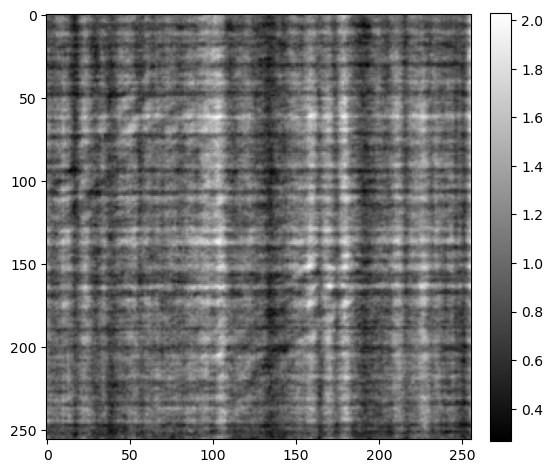

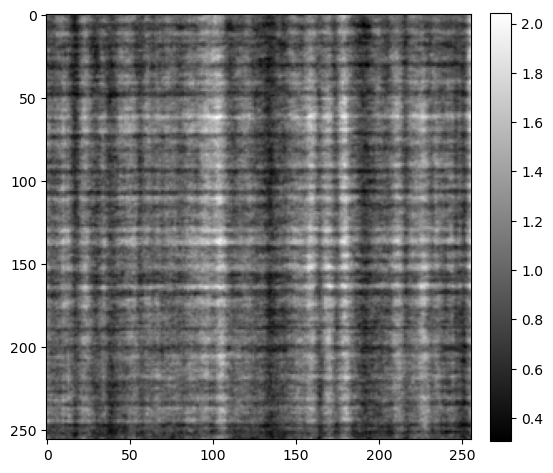

In [9]:
mshow(cl.data[0,0],True)
mshow(cl.ref[0],True)

## Reconstruction

Reset variables to the (imperfect) initial guess and run the iterative solver.
No writer is passed, so `vis_debug` will display inline plots instead of saving checkpoints.

2026-03-26 17:40:11 [rank=0] iter=0: 2.2836sec err=6.58459e-03 


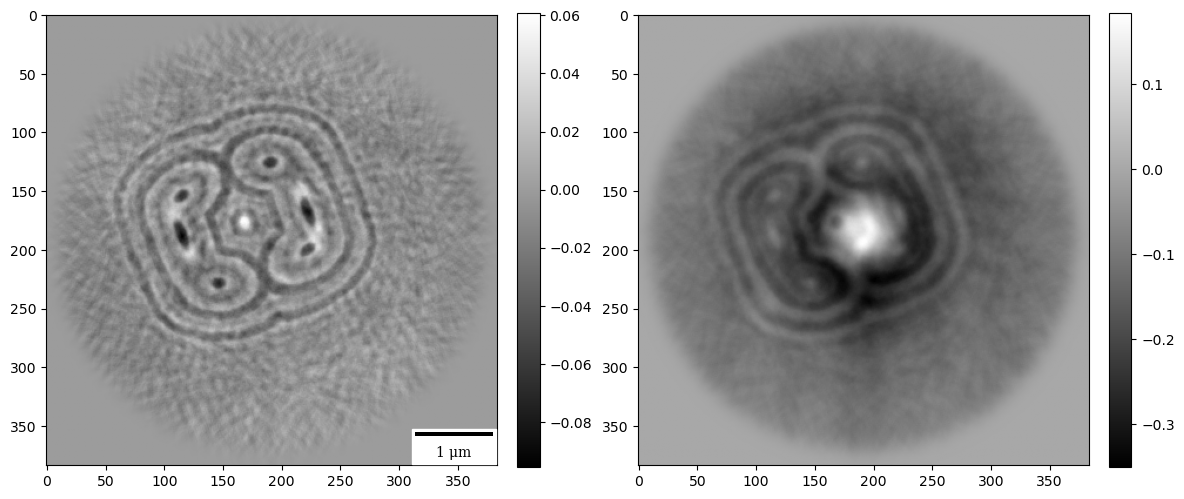

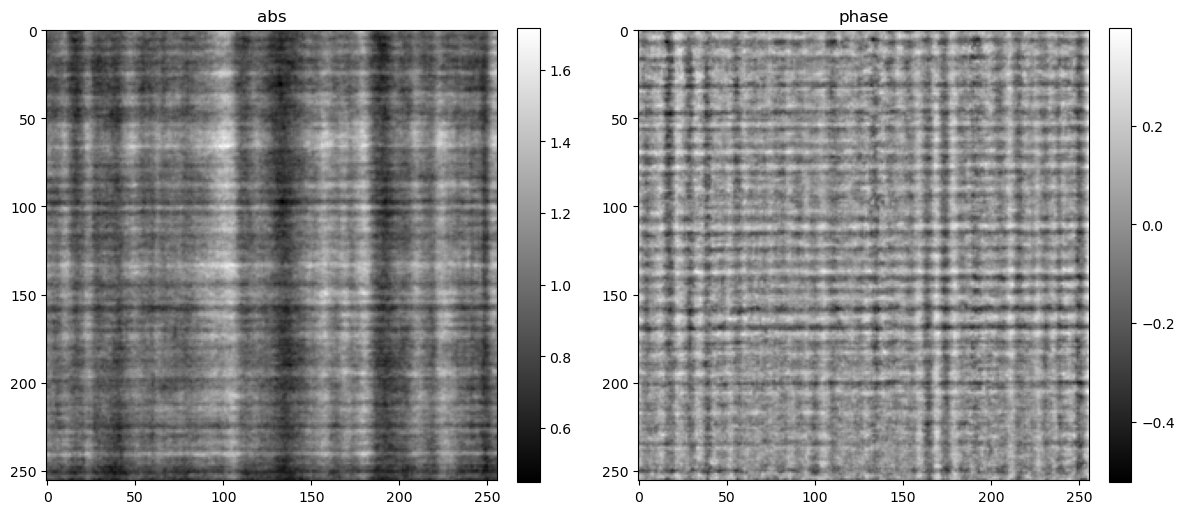

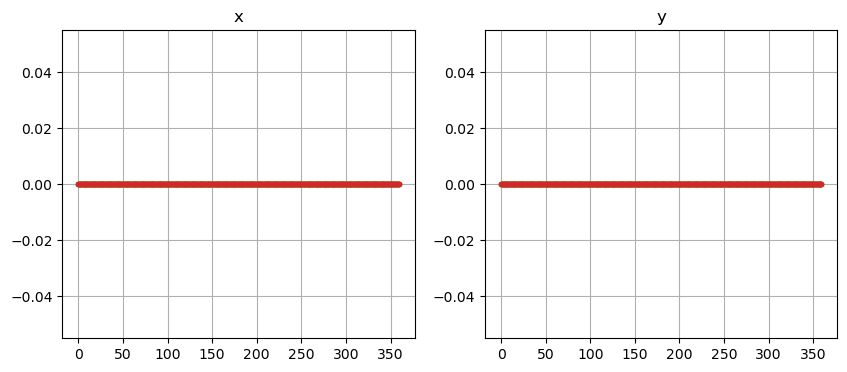

2026-03-26 17:40:33 [rank=0] iter=16: 21.3359sec err=2.05416e-04 


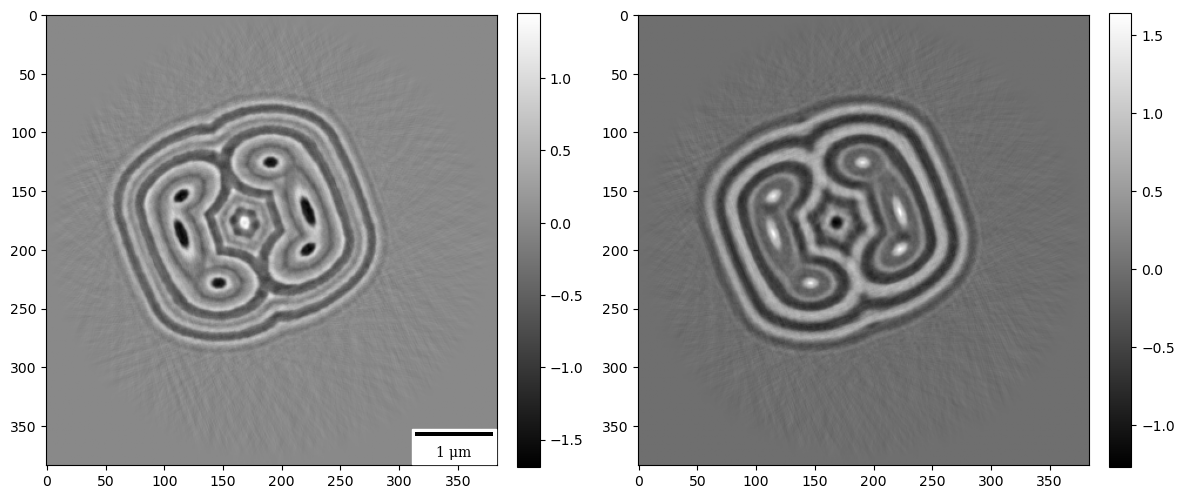

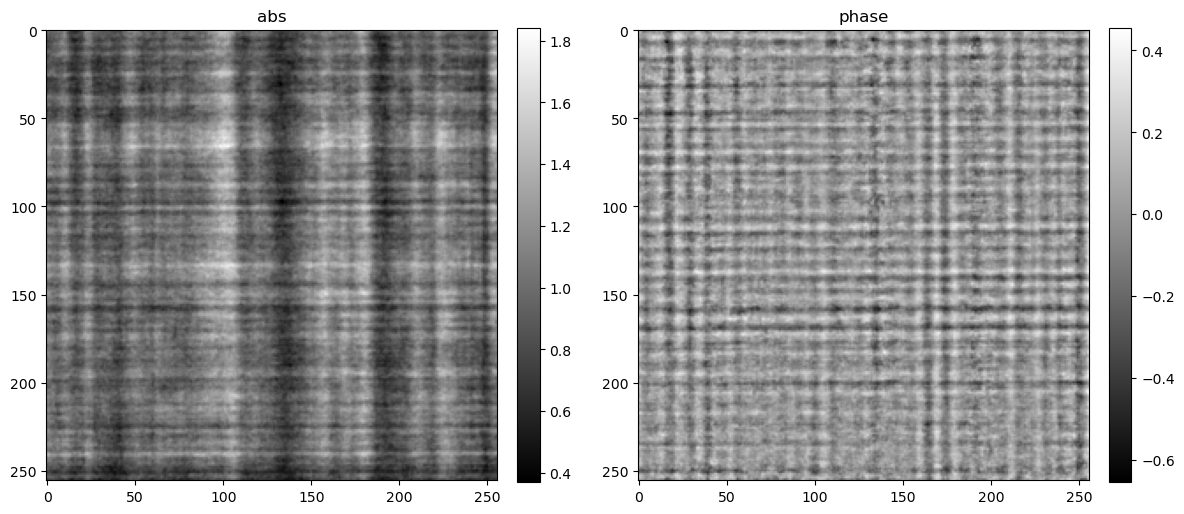

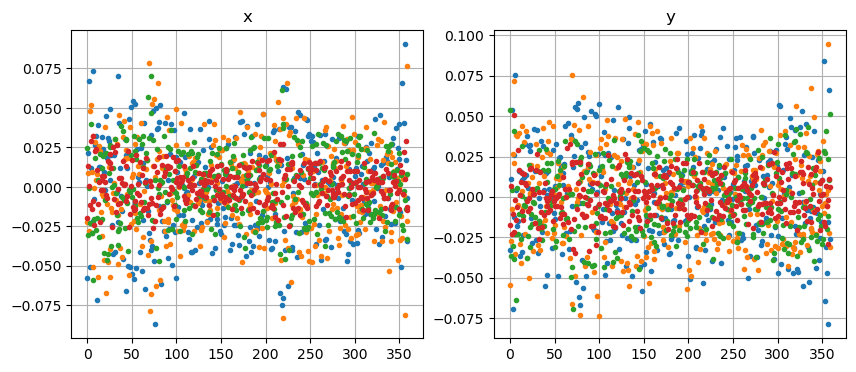

In [ ]:
# Initial guess: flat object, flat probe, positions perturbed by pos_err
cl.vars['obj'][:] = 0
cl.vars['prb'][:] = cp.array(1)
cl.vars['pos'][:] = cp.array(pos + pos_err)

cl.BH()